### Step 1: Install the required library (once)

In [1]:
pip install sqlalchemy psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 6.9 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Step 2: Create the PostgreSQL connection

In [2]:
import pandas as pd
from sqlalchemy import create_engine

In [5]:
# PostgreSQL Connection

DB_USER = "santharao"
DB_PASSWORD = ""
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "powerwash_analytics"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

### Step 3: Read directly from PostgreSQL

In [6]:
query = """
SELECT *
FROM player_logged_in
"""

df = pd.read_sql(query, engine)

df.head()

,pid,EventName,Time,Time_utc
0,p1,player_logged_in,2022-08-18 17:53:05,2022-08-18 22:53:05
1,p1,player_logged_in,2022-08-18 18:38:17,2022-08-18 23:38:17
2,p1,player_logged_in,2022-08-18 18:55:00,2022-08-18 23:55:00
3,p1,player_logged_in,2022-08-18 21:53:33,2022-08-19 02:53:33
4,p1,player_logged_in,2022-08-19 13:14:26,2022-08-19 18:14:26


### Visualization 1 ⭐⭐⭐⭐⭐
#### Research Question

##### What does the login activity look like over the entire study period?

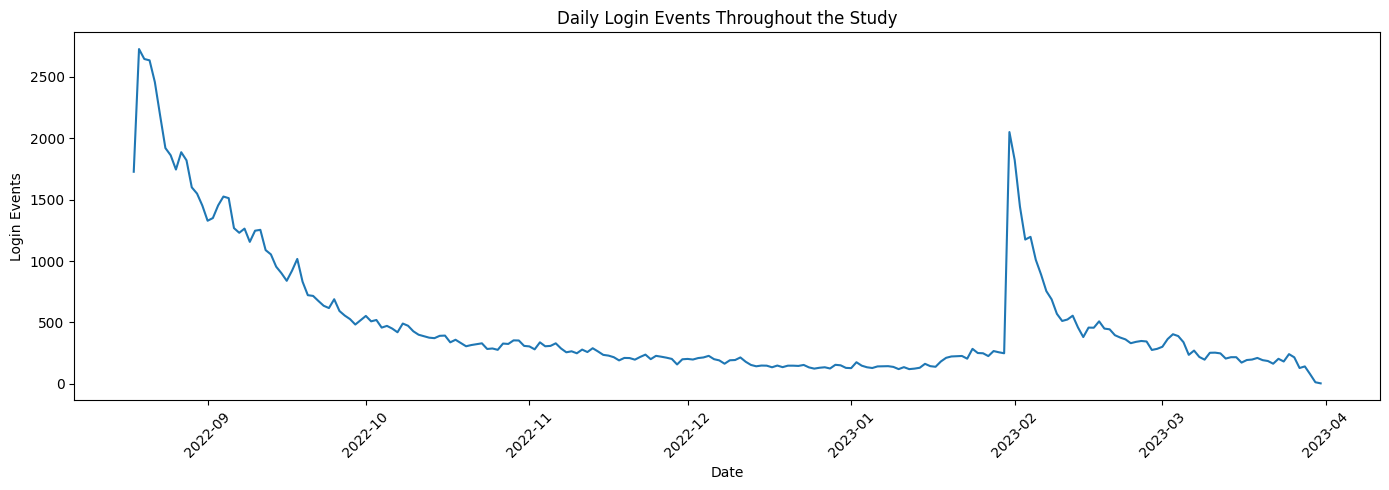

In [8]:
import matplotlib.pyplot as plt

df["Time"] = pd.to_datetime(df["Time"])

daily_logins = (
    df.groupby(df["Time"].dt.date)
      .size()
      .reset_index(name="login_events")
)

plt.figure(figsize=(14,5))

plt.plot(
    daily_logins["Time"],
    daily_logins["login_events"]
)

plt.title("Daily Login Events Throughout the Study")
plt.xlabel("Date")
plt.ylabel("Login Events")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Research Notes

    declining trend? Periodic declines
    spikes? Yes, Found one
    weekends? Not an evident change
    acquisition periods? Yet to figure out and have to check if there is any massive acquisition happened during the spike. At the same time have to figure out the reason for the spike by understanding what happened exactly at the specific time i.e, in Feb,2023.

### Visualization 2 ⭐⭐⭐⭐⭐
#### Research Question

##### How many login sessions does each player have?

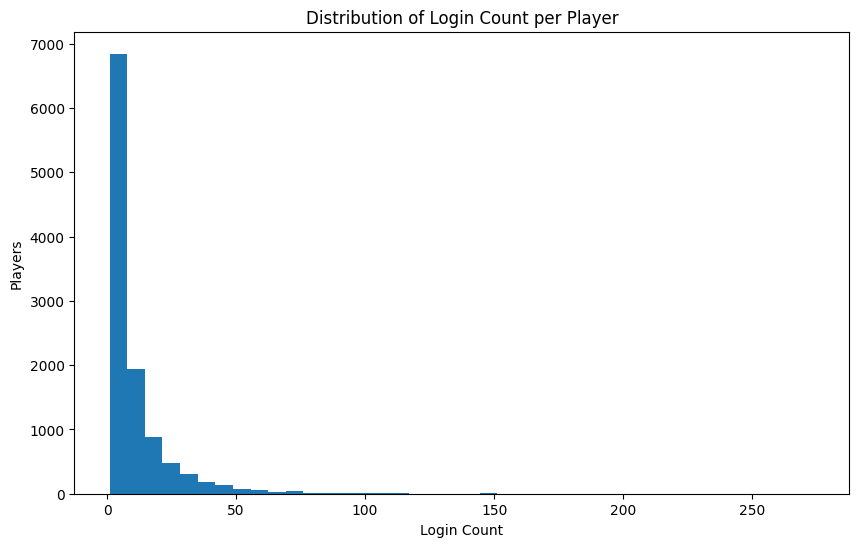

In [9]:
login_frequency = (
    df.groupby("pid")
      .size()
      .reset_index(name="login_count")
)

plt.figure(figsize=(10,6))

plt.hist(
    login_frequency["login_count"],
    bins=40
)

plt.title("Distribution of Login Count per Player")
plt.xlabel("Login Count")
plt.ylabel("Players")

plt.show()

### Observe:

    Long tail? Yes
    Right skew? Yes
    Multiple clusters? Yes

We found this already in demographics as far as I remember.

### Visualization 3 ⭐⭐⭐⭐⭐
#### Research Question

##### How many players belong to each login-count bucket?

In [10]:
bins = [1,2,5,10,20,50,100,300]

labels = [
    "1",
    "2-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    "100+"
]

login_frequency["bucket"] = pd.cut(
    login_frequency["login_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

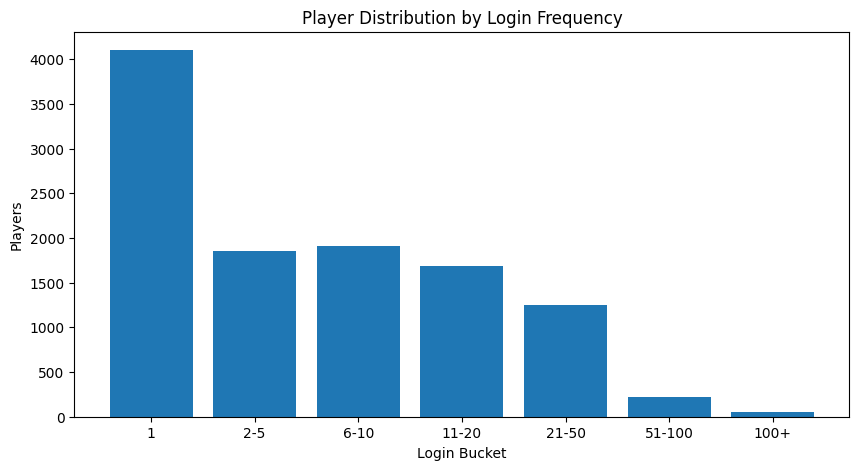

In [11]:
bucket_counts = (
    login_frequency["bucket"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

plt.bar(
    bucket_counts.index.astype(str),
    bucket_counts.values
)

plt.title("Player Distribution by Login Frequency")

plt.xlabel("Login Bucket")

plt.ylabel("Players")

plt.show()

It looks interesting here. Log-in count seems to be much stable from day 2 to day 20. It looks decent from day 20 to day 50 as well. Post that there are very less registered. I would like to understand better why exactly the second day log-in count is half or less of the first day. Finding the reasons is the primary task from here as increasing the log-in count from 2-5  days would definitely increase the log-in count for the further bins as per the above chart as log-in count has been stable from 2-20 and with slight drop from 21-50. I strongly feel there is something happening on Day1 to investigate.

### Visualization 4 ⭐⭐⭐⭐☆
#### Research Question

##### What percentage of players logged in only once?

In [15]:
login_frequency = (
    df.groupby("pid")
      .size()
      .reset_index(name="login_count")
)

login_frequency["player_type"] = login_frequency["login_count"].apply(
    lambda x: "Single Login" if x == 1 else "Returned"
)

player_type_counts = (
    login_frequency["player_type"]
    .value_counts()
)

player_type_counts

player_type
Returned        8248
Single Login    2832
Name: count, dtype: int64

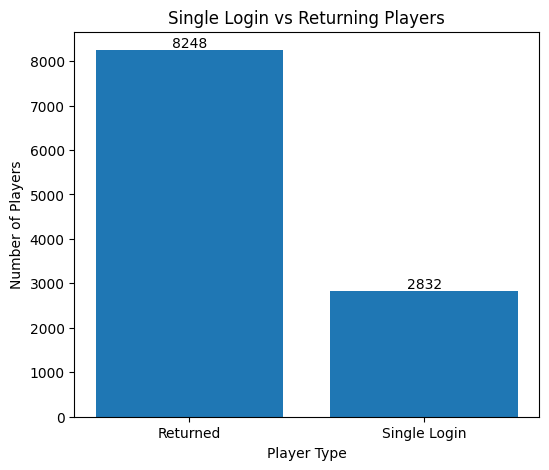

In [16]:
plt.figure(figsize=(6,5))

plt.bar(
    player_type_counts.index,
    player_type_counts.values
)

plt.title("Single Login vs Returning Players")
plt.xlabel("Player Type")
plt.ylabel("Number of Players")

for i, value in enumerate(player_type_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.show()

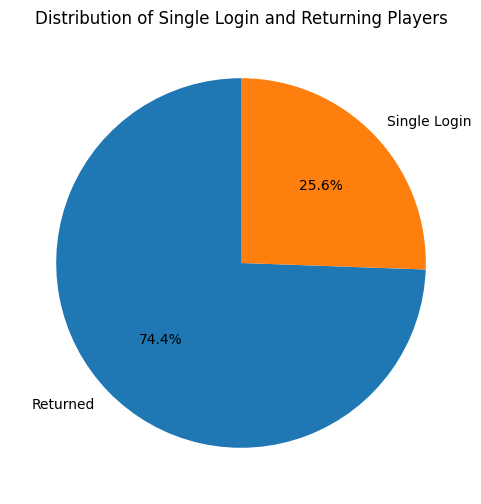

In [17]:
plt.figure(figsize=(6,6))

plt.pie(
    player_type_counts.values,
    labels=player_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Single Login and Returning Players")

plt.show()

### Visualization 5 – Days Between Logins

In [18]:
df = df.sort_values(["pid", "Time"])

df["Previous_Login"] = (
    df.groupby("pid")["Time"]
      .shift(1)
)

df["Days_Between_Logins"] = (
    df["Time"] - df["Previous_Login"]
).dt.days

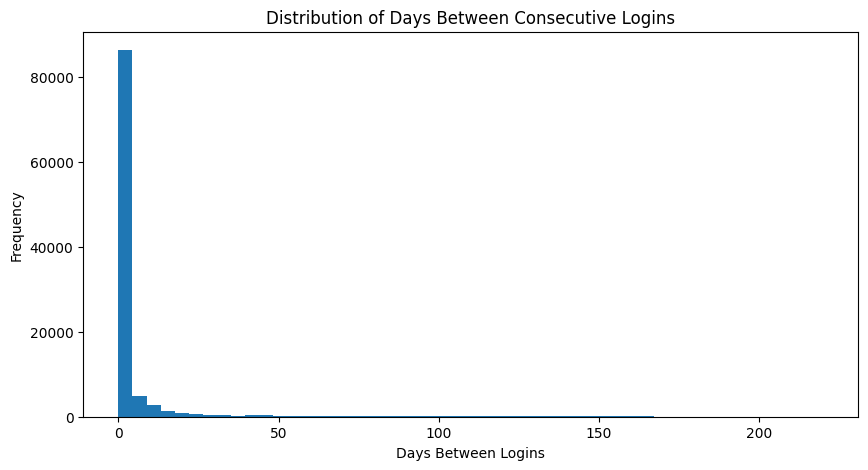

In [20]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Days_Between_Logins"].dropna(),
    bins=50
)

plt.title("Distribution of Days Between Consecutive Logins")
plt.xlabel("Days Between Logins")
plt.ylabel("Frequency")

plt.show()

Again one more interesting point is that if player is not logging in the very next day then the chances of getting the player back reduced drastically. After few days it goes almost near to 0. Probably this will help us in defining the way to consider the players whether churned or not based on the last login.

### Visualization 6 – Login Count Boxplot

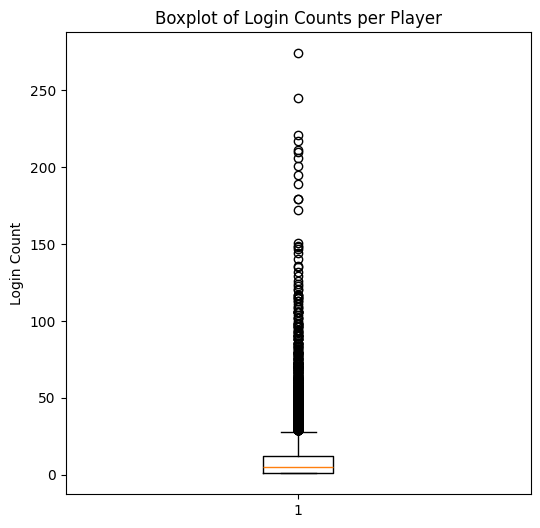

In [21]:
plt.figure(figsize=(6,6))

plt.boxplot(
    login_frequency["login_count"]
)

plt.title("Boxplot of Login Counts per Player")
plt.ylabel("Login Count")

plt.show()

There are many outliers as such I could see values near to 25 or 30 seems to be the region

### Visualization 7 – Cumulative Distribution (Very Important)

In [22]:
login_frequency = login_frequency.sort_values("login_count")

login_frequency["cumulative_percentage"] = (
    (range(1, len(login_frequency)+1))
)

login_frequency["cumulative_percentage"] = (
    login_frequency["cumulative_percentage"] /
    len(login_frequency)
) * 100

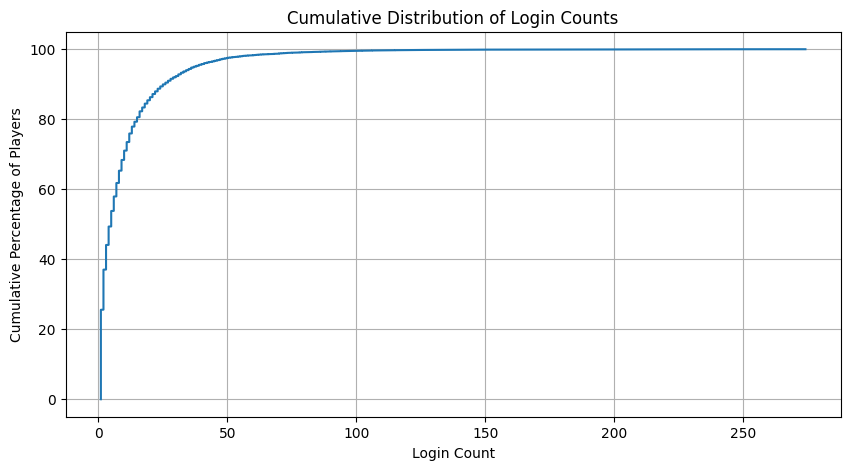

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    login_frequency["login_count"],
    login_frequency["cumulative_percentage"]
)

plt.title("Cumulative Distribution of Login Counts")
plt.xlabel("Login Count")
plt.ylabel("Cumulative Percentage of Players")

plt.grid(True)

plt.show()

It says something we observed earlier that there is a decline post 50-60 as we can see very few jumps from there.

### Visualization 8 – Study Duration vs Login Count

In [24]:
player_summary = (
    df.groupby("pid")
      .agg(
          first_login=("Time", "min"),
          last_login=("Time", "max"),
          login_count=("Time", "count")
      )
      .reset_index()
)

player_summary["study_duration_days"] = (
    player_summary["last_login"] -
    player_summary["first_login"]
).dt.days

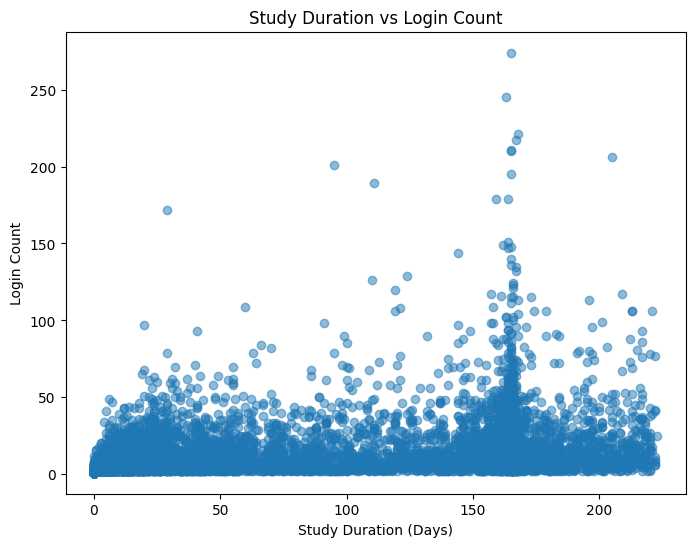

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    player_summary["study_duration_days"],
    player_summary["login_count"],
    alpha=0.5
)

plt.title("Study Duration vs Login Count")
plt.xlabel("Study Duration (Days)")
plt.ylabel("Login Count")

plt.show()